In [37]:
import numpy as np
import cv2
import PIL
import PIL.Image as Image
import os
import h5py

import matplotlib.pylab as plt

import tensorflow as tf

from tensorflow.keras.applications import InceptionV3
from tensorflow import keras
from tensorflow.keras import layers, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

In [20]:
# Load the dataset with your custom Dataset class
# Download latest version
import pathlib
data_dir = pathlib.Path("C:/Users/franz/Downloads/animal_dataset/animals/animals")


In [21]:
print("Dataset path:", data_dir)
print("Contents of the directory:", list(data_dir.iterdir())) 

Dataset path: C:\Users\franz\Downloads\animal_dataset\animals\animals
Contents of the directory: [WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/antelope'), WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/badger'), WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/bat'), WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/bear'), WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/bee'), WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/beetle'), WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/bison'), WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/boar'), WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/butterfly'), WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/cat'), WindowsPath('C:/Users/franz/Downloads/animal_dataset/animals/animals/caterpillar'), WindowsPath('C:/Users/franz/Downloads

In [22]:
#Label the data

animal_images_dict = {
    'zebra': list(data_dir.glob('zebra/*')),
    'woodpecker': list(data_dir.glob('woodpecker/*')),
    'wombat': list(data_dir.glob('wombat/*')),
}

animal_labels_dict = {
    'zebra': 0,
    'woodpecker': 1,
    'wombat': 2,
}

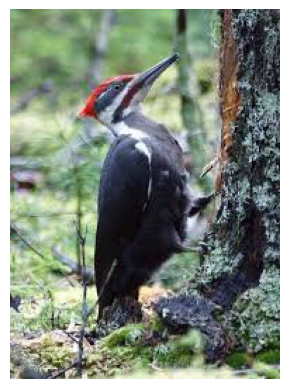

In [23]:
#Display the image data

import cv2
import matplotlib.pyplot as plt

# Read the first zebra image from animal_images_dict
first_image_path = str(animal_images_dict['woodpecker'][0])
img = cv2.imread(first_image_path)

# Convert from BGR (OpenCV default) to RGB for correct color display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [24]:
#Check image shape
img = cv2.imread(str(animal_images_dict['zebra'][0]))
img.shape

(900, 1075, 3)

In [25]:
X, y = [], []

for animal, images in animal_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(animal_labels_dict[animal])

In [26]:
#Check new dataset shape
first_image = X[0] 
print(f"First image shape: {first_image.shape}")

First image shape: (180, 180, 3)


In [27]:
#Convert variables to numpy arrays
X = np.array(X)
y = np.array(y)

In [28]:
#Split Dataset into training and testing sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)


#Scale the images
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [29]:
#Define data augmentation parameters

data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=(180, 180,3)),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1)
  ]
)
 

In [30]:
#Load the Model
base_model = InceptionV3(input_shape=(180, 180, 3), include_top=False, weights='imagenet')

#Freeze the base model
base_model.trainable = False

In [31]:
#Add custom layers
inputs = Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.7)(x)
x = layers.Dense(3, activation='relu')(x)
output = Dense(3, activation='softmax')(x)

In [32]:
#Create the final model
model = Model(inputs, outputs=output)
#Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 4, 4, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         6,147 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,808,943 (83.19 MB)

 Trainable params: 6,159 (24.06 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [33]:
#Fit the model
model.fit(X_train_scaled, y_train, epochs=30, validation_data=(X_test_scaled, y_test))

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3658 - loss: 1.5013 - val_accuracy: 0.3333 - val_loss: 1.0278
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 848ms/step - accuracy: 0.4472 - loss: 1.0749 - val_accuracy: 0.6000 - val_loss: 0.9422
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4300 - loss: 1.0637 - val_accuracy: 0.6222 - val_loss: 0.9035
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 778ms/step - accuracy: 0.5071 - loss: 0.9417 - val_accuracy: 0.6222 - val_loss: 0.8564
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 640ms/step - accuracy: 0.5417 - loss: 1.0115 - val_accuracy: 0.6000 - val_loss: 0.8092
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 737ms/step - accuracy: 0.6212 - loss: 0.8439 - val_accuracy: 0.6000 - val_loss: 0.7830
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 700ms/step - accuracy: 0.5178 - loss: 0.9125 - val_accuracy: 0.6000 - val_loss: 0.7677
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 602ms/step - accuracy: 0.5634 - loss: 0.8907 - val_accuracy: 0.6222 - val_loss: 0.75

In [34]:
model.evaluate(X_test_scaled,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - accuracy: 1.0000 - loss: 0.1568


[0.15556837618350983, 1.0]

In [ ]:
model.save('inception_transfer_learning.keras')

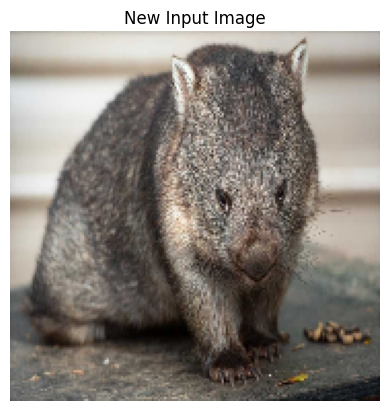

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Predicted label: wombat


In [ ]:
#Test model with new data

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define an inverse lookup dictionary
label_map = {0: 'zebra', 1: 'woodpecker', 2: 'wombat'}

# Path to your new image (adjust the path accordingly)
new_image_path = r"C:\Users\franz\Desktop\DIT\Intelligent Systems 2\reporting_activity\test\wombat.jpg"

# Read and preprocess the image
img = cv2.imread(new_image_path)
img = cv2.resize(img, (180, 180))
# Convert BGR to RGB if you want to display it correctly
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Scale the image as done for training
img_scaled = img_rgb / 255.0
# Expand dims to create a batch of size 1
img_batch = np.expand_dims(img_scaled, axis=0)

#Optionally display the new image
plt.imshow(img_scaled)
plt.axis("off")
plt.title("New Input Image")
plt.show()

# Make a prediction
preds = model.predict(img_batch)
predicted_index = np.argmax(preds, axis=1)[0]
predicted_label = label_map[predicted_index]

print(f"Predicted label: {predicted_label}")